In [1]:
print("Simple regression analysis:")

Simple regression analysis:


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 

In [5]:
df = pd.read_csv("../data/JE001_real_sample.csv")

In [7]:
df.head(9)

,date,tickets_sold,instagram_followers,reel_views,days_advertised,day_of_week,month,student_term_time,weather,rainfall,temperature
0,19/07/26,9,49,674,14,Sunday,July,Summer Break,Sunny,0mm,24C
1,23/07/26,11,57,898,18,Thursday,July,Summer Break,Cloudy,0mm,19C
2,28/07/26,18,73,1535,23,Tuesday,July,Summer Break,Sunny,0mm,25C
3,31/07/26,19,74,1569,26,Friday,July,Summer Break,Sunny,0mm,20C
4,06/08/26,25,76,1593,32,Thursday,August,Summer Break,Cloudy,1mm,15C
5,08/08/26,32,77,1603,34,Saturday,August,Summer Break,Sunny,0mm,20C
6,12/08/26,41,78,1642,38,Wednesday,August,Summer Break,Sunny,0mm,26C
7,17/08/26,53,81,1687,43,Monday,August,Summer Break,Cloudy,1mm,20C
8,21/08/26,98,91,1852,48,Friday,August,Summer Break,Sunny,0mm,21C


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   date                 9 non-null      str  
 1   tickets_sold         9 non-null      int64
 2   instagram_followers  9 non-null      int64
 3   reel_views           9 non-null      int64
 4   days_advertised      9 non-null      int64
 5   day_of_week          9 non-null      str  
 6   month                9 non-null      str  
 7   student_term_time    9 non-null      str  
 8   weather              9 non-null      str  
 9   rainfall             9 non-null      str  
 10  temperature          9 non-null      str  
dtypes: int64(4), str(7)
memory usage: 924.0 bytes


,tickets_sold,instagram_followers,reel_views,days_advertised
count,9.000000,9.000000,9.000000,9.000000
mean,34.000000,72.888889,1450.333333,30.666667
std,27.897132,12.604012,391.592901,11.390786
min,9.000000,49.000000,674.000000,14.000000
25%,18.000000,73.000000,1535.000000,23.000000
50%,25.000000,76.000000,1593.000000,32.000000
75%,41.000000,78.000000,1642.000000,38.000000
max,98.000000,91.000000,1852.000000,48.000000


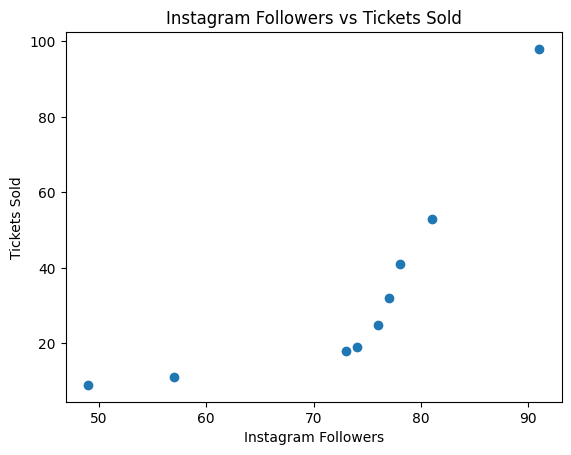

In [9]:
plt.scatter(df["instagram_followers"], df["tickets_sold"])
plt.xlabel("Instagram Followers")
plt.ylabel("Tickets Sold")
plt.title("Instagram Followers vs Tickets Sold")
plt.show()

In [10]:
df["instagram_followers"].corr(df["tickets_sold"])

np.float64(0.8023672788607026)

In [12]:
X = df["instagram_followers"]
y = df["tickets_sold"]
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           tickets_sold   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     12.65
Date:                Sat, 29 Aug 2026   Prob (F-statistic):            0.00926
Time:                        09:23:11   Log-Likelihood:                -37.552
No. Observations:                   9   AIC:                             79.10
Df Residuals:                       7   BIC:                             79.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -95.4450    

In [13]:
print(model.params)

const                 -95.445008
instagram_followers     1.775922
dtype: float64


In [14]:
print(model.rsquared)

0.6437932501863285


In [15]:
print(model.rsquared_adj)

0.5929065716415183


In [17]:
print(model.pvalues["instagram_followers"])

0.009257831613722674


In [36]:
new_event = pd.DataFrame({"const": [1], "instagram_followers": [100]})
prediction = model.predict(new_event)
print(prediction)

0    82.147229
dtype: float64


In [37]:
df["predicted_sales"] = model.predict(X)

In [38]:
df[["instagram_followers", "tickets_sold", "predicted_sales"]].head(10)

,instagram_followers,tickets_sold,predicted_sales
0,49,9,-8.424812
1,57,11,5.782567
2,73,18,34.197325
3,74,19,35.973247
4,76,25,39.525092
5,77,32,41.301014
6,78,41,43.076937
7,81,53,48.404704
8,91,98,66.163927


In [40]:
df["residual"] = df["tickets_sold"] - df["predicted_sales"]

In [41]:
df[["tickets_sold", "predicted_sales", "residual"]].head(10)

,tickets_sold,predicted_sales,residual
0,9,-8.424812,17.424812
1,11,5.782567,5.217433
2,18,34.197325,-16.197325
3,19,35.973247,-16.973247
4,25,39.525092,-14.525092
5,32,41.301014,-9.301014
6,41,43.076937,-2.076937
7,53,48.404704,4.595296
8,98,66.163927,31.836073


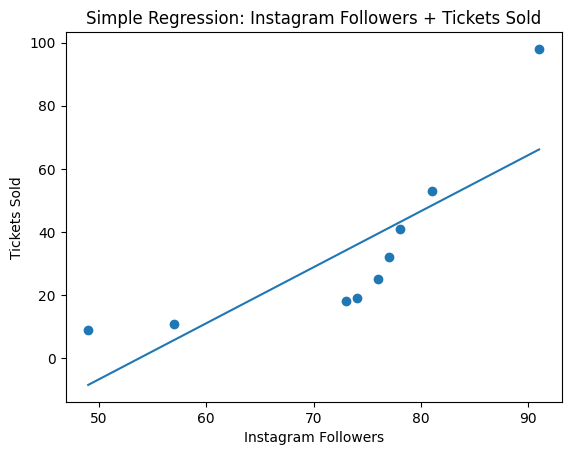

In [42]:
plt.scatter(df["instagram_followers"], df["tickets_sold"])
plt.plot(df["instagram_followers"], df["predicted_sales"])
plt.xlabel("Instagram Followers")
plt.ylabel("Tickets Sold")
plt.title("Simple Regression: Instagram Followers + Tickets Sold")
plt.show()

In [2]:
print("Multiple regression analysis:")

Multiple regression analysis:


In [44]:
df.columns

Index(['date', 'tickets_sold', 'instagram_followers', 'reel_views',
       'days_advertised', 'day_of_week', 'month', 'student_term_time',
       'weather', 'rainfall', 'temperature', 'predicted_sales', 'residual'],
      dtype='str')

In [56]:
y = df["tickets_sold"]
X = df[["instagram_followers", "reel_views", "days_advertised"]]

In [57]:
X = sm.add_constant(X)
multiple_model = sm.OLS(y,X).fit() 
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:           tickets_sold   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     57.43
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           0.000269
Time:                        09:43:30   Log-Likelihood:                -26.140
No. Observations:                   9   AIC:                             60.28
Df Residuals:                       5   BIC:                             61.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -221.8539    

In [58]:
print(multiple_model.params)

const                 -221.853863
instagram_followers      6.979252
reel_views              -0.186093
days_advertised          0.555658
dtype: float64


In [59]:
print(multiple_model.pvalues)

const                  0.003428
instagram_followers    0.004619
reel_views             0.002933
days_advertised        0.408284
dtype: float64


In [60]:
print(multiple_model.conf_int())

                              0           1
const               -331.240867 -112.466858
instagram_followers    3.290442   10.668062
reel_views            -0.274617   -0.097569
days_advertised       -1.027458    2.138774


In [61]:
print("R²:", multiple_model.rsquared)

R²: 0.9717975894194172


In [62]:
print("Adjusted R²:", multiple_model.rsquared_adj)

Adjusted R²: 0.9548761430710675


In [63]:
print("Simple R²:", model.rsquared)
print("Multiple R²:", multiple_model.rsquared)

print("Simple Adjusted R²:", model.rsquared_adj)
print("Multiple Adjusted R²:", multiple_model.rsquared_adj)

Simple R²: 0.6437932501863285
Multiple R²: 0.9717975894194172
Simple Adjusted R²: 0.5929065716415183
Multiple Adjusted R²: 0.9548761430710675


In [64]:
new_event = pd.DataFrame({"const": [1], "isntagram_followers": [100], "reel_views": [2000], "days_advertised": [45]})

In [65]:
prediction = multiple_model.predict(new_event)

In [66]:
print("Predicted ticket sales:", prediction.iloc[0])

Predicted ticket sales: 128.89083094130964


In [67]:
df["predicted_sales"] = multiple_model.predict(X)

In [69]:
df[["tickets_sold", "predicted_sales"]].head(10)

,tickets_sold,predicted_sales
0,9,2.482319
1,11,18.854233
2,18,14.759593
3,19,17.078671
4,25,29.904900
5,32,36.134542
6,41,38.078815
7,53,53.420695
8,98,95.286233


In [3]:
print("Interpretation of results:")

Interpretation of results:


In [72]:
results = pd.DataFrame({"Coefficient": multiple_model.params, "P-value": multiple_model.pvalues, "Lower CI": multiple_model.conf_int()[0], "Upper CI": multiple_model.conf_int()[1]})
print(results)

                     Coefficient   P-value    Lower CI    Upper CI
const                -221.853863  0.003428 -331.240867 -112.466858
instagram_followers     6.979252  0.004619    3.290442   10.668062
reel_views             -0.186093  0.002933   -0.274617   -0.097569
days_advertised         0.555658  0.408284   -1.027458    2.138774


In [73]:
significant = results[results["P-value"] < 0.05]
print(significant)

                     Coefficient   P-value    Lower CI    Upper CI
const                -221.853863  0.003428 -331.240867 -112.466858
instagram_followers     6.979252  0.004619    3.290442   10.668062
reel_views             -0.186093  0.002933   -0.274617   -0.097569


In [74]:
not_significant = results[results["P-value"] >= 0.05]
print(not_significant)

                 Coefficient   P-value  Lower CI  Upper CI
days_advertised     0.555658  0.408284 -1.027458  2.138774


In [75]:
results.sort_values("P-value")

,Coefficient,P-value,Lower CI,Upper CI
reel_views,-0.186093,0.002933,-0.274617,-0.097569
const,-221.853863,0.003428,-331.240867,-112.466858
instagram_followers,6.979252,0.004619,3.290442,10.668062
days_advertised,0.555658,0.408284,-1.027458,2.138774


In [78]:
results["Direction"] = results["Coefficient"].apply(lambda x: "Positive" if x > 0 else "Negative")
print(results)

                     Coefficient   P-value    Lower CI    Upper CI Direction
const                -221.853863  0.003428 -331.240867 -112.466858  Negative
instagram_followers     6.979252  0.004619    3.290442   10.668062  Positive
reel_views             -0.186093  0.002933   -0.274617   -0.097569  Negative
days_advertised         0.555658  0.408284   -1.027458    2.138774  Positive


In [79]:
df["predicted_sales"] = multiple_model.predict(X)

In [80]:
df["residual"] = df["tickets_sold"] - df["predicted_sales"]

In [81]:
df["absolute_error"] = abs(df["residual"])
df.sort_values("absolute_error", ascending=False).head(10)

,date,tickets_sold,instagram_followers,reel_views,days_advertised,day_of_week,month,student_term_time,weather,rainfall,temperature,predicted_sales,residual,absolute_error
1,23/07/26,11,57,898,18,Thursday,July,1,Cloudy,0mm,19C,18.854233,-7.854233,7.854233
0,19/07/26,9,49,674,14,Sunday,July,1,Sunny,0mm,24C,2.482319,6.517681,6.517681
4,06/08/26,25,76,1593,32,Thursday,August,1,Cloudy,1mm,15C,29.904900,-4.904900,4.904900
5,08/08/26,32,77,1603,34,Saturday,August,1,Sunny,0mm,20C,36.134542,-4.134542,4.134542
2,28/07/26,18,73,1535,23,Tuesday,July,1,Sunny,0mm,25C,14.759593,3.240407,3.240407
6,12/08/26,41,78,1642,38,Wednesday,August,1,Sunny,0mm,26C,38.078815,2.921185,2.921185
8,21/08/26,98,91,1852,48,Friday,August,1,Sunny,0mm,21C,95.286233,2.713767,2.713767
3,31/07/26,19,74,1569,26,Friday,July,1,Sunny,0mm,20C,17.078671,1.921329,1.921329
7,17/08/26,53,81,1687,43,Monday,August,1,Cloudy,1mm,20C,53.420695,-0.420695,0.420695


In [84]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(df["tickets_sold"], df["predicted_sales"])
print("MAE:", mae)

MAE: 3.847637758823541


Text(0.5, 1.0, 'Actual vs Predicted Ticket Sales')

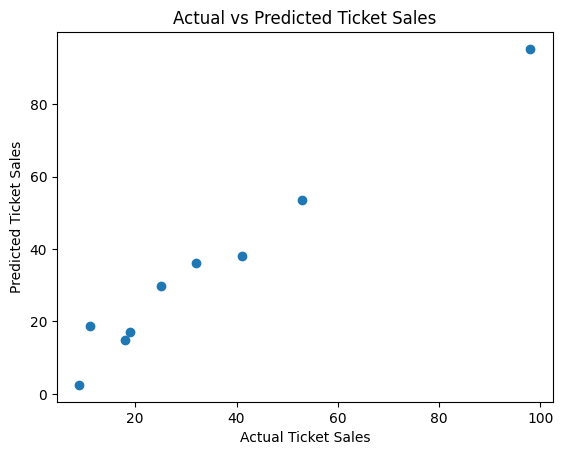

In [85]:
plt.scatter(df["tickets_sold"],df["predicted_sales"])
plt.xlabel("Actual Ticket Sales")
plt.ylabel("Predicted Ticket Sales")
plt.title("Actual vs Predicted Ticket Sales")

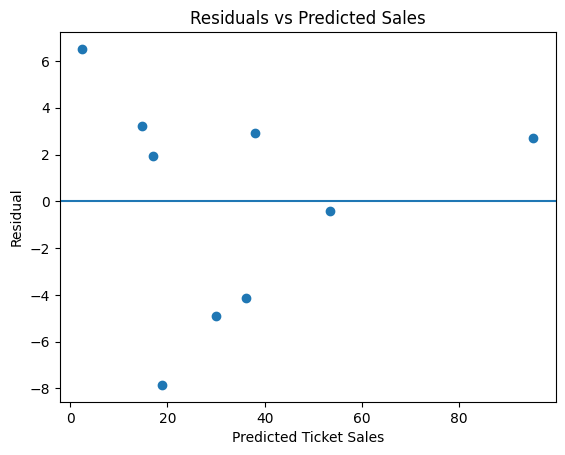

In [86]:
plt.scatter(df["predicted_sales"],df["residual"])
plt.axhline(y=0)
plt.xlabel("Predicted Ticket Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sales")
plt.show()

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)for i in range(X.shape[1])]
print(vif)

              Variable         VIF
0                const  464.072416
1  instagram_followers   74.523283
2           reel_views   41.427973
3      days_advertised   11.210749


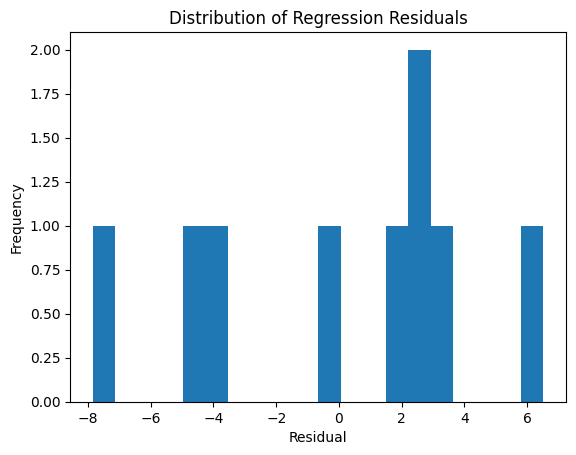

In [89]:
plt.hist(df["residual"], bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")
plt.show()

In [90]:
print(multiple_model.summary())
print("R² =", multiple_model.rsquared)
print("Adjusted R² =", multiple_model.rsquared_adj)
print("MAE =", mae)

                            OLS Regression Results                            
Dep. Variable:           tickets_sold   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     57.43
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           0.000269
Time:                        10:05:41   Log-Likelihood:                -26.140
No. Observations:                   9   AIC:                             60.28
Df Residuals:                       5   BIC:                             61.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -221.8539    